In [1]:
# Importar bibliotecas
import matplotlib.pyplot as plt
#import matplotlib.font_manager as font_manager
import numpy as np
#import cv2 as cv
from scipy.optimize import curve_fit

In [2]:
def loadReconstructedVolume(fileName):
    #print(fileName)
    img = np.load(fileName)

    #print(img.shape)

    #img = img.reshape((dimX, dimY, dimZ))
    return img

In [3]:
folderName = 'C:/workspace/Michel_Dual_Energy/imgRecons/' 
fileName = 'img2Bins_60_120_60keV.npy'

# A imagem 3D deveria ser 400x400x400, por um probleminha ao mandar a reconstruir omitimos o 
# ultimo slice, por isso o tamanho real é 399x400x400
# Isto é 399 slices de 400x400
img60k = loadReconstructedVolume(folderName+fileName)#, 399, 400, 400, 'float64')

In [4]:
print(img60k.shape)

(271, 400, 400)


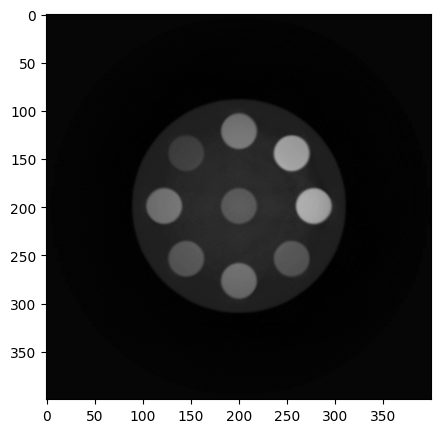

In [5]:
plt.rcParams["figure.figsize"]=5,5
fig = plt.figure()
ax = plt.axes()
ax.imshow(img60k[270,:,:], cmap='gray', vmin=0, vmax=65535)

In [6]:
maxV60k = img60k.max()
minxV60k = img60k.min()
meanxV60k = img60k.mean()
print(maxV60k, minxV60k, meanxV60k)

46198 0 4997.029076222325


In [7]:
histogram, bin_edges = np.histogram(img60k, bins=4095, range=(0, 65535))

In [8]:
print(histogram.shape)
print(bin_edges.shape)

(4095,)
(4096,)


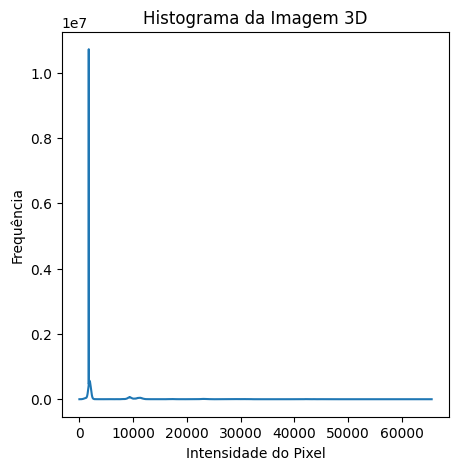

In [9]:
# Plotar histograma
plt.figure()
plt.plot(bin_edges[0:-1], histogram)  # bin_edges tem um elemento a mais que histogram
plt.title('Histograma da Imagem 3D')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.show()

C:\Users\dsdom\AppData\Local\Temp\ipykernel_2148\411980752.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(bin_edges[0:-1], np.log(histogram))  # bin_edges tem um elemento a mais que histogram


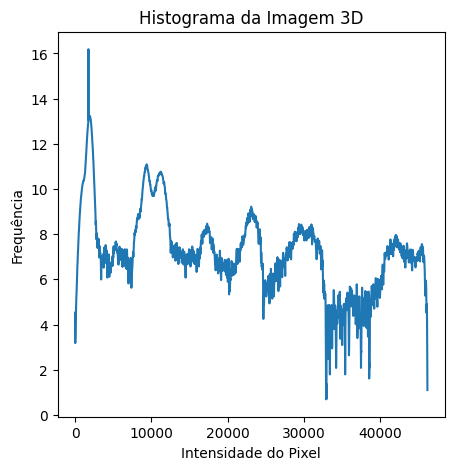

In [10]:
# Plotar histograma
plt.figure()
plt.plot(bin_edges[0:-1], np.log(histogram))  # bin_edges tem um elemento a mais que histogram
plt.title('Histograma da Imagem 3D')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.show()

In [11]:
print(np.argmax(histogram))

109


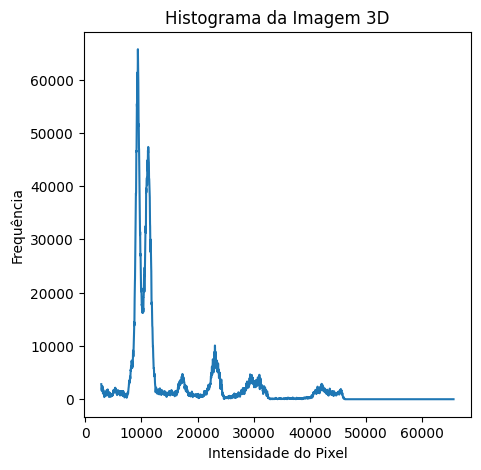

In [12]:
# Plotar histograma
plt.figure()
plt.plot(bin_edges[180:], histogram[179:])  # bin_edges tem um elemento a mais que histogram
plt.title('Histograma da Imagem 3D')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.show()

In [13]:
magnification = 50/45
voxel = 0.03
cilR = 0.5
cilH = 8
cilindMascDataCenter = [(0, 0, 0),          #0
                        (0, -2.1, 0),       #1
                        (1.48, -1.48, 0),   #2
                        (2.1, 0, 0),        #3
                        (1.48, 1.48, 0),    #4
                        (0, 2.1, 0),        #5
                        (-1.48, 1.48, 0),   #6
                        (-2.1, 0, 0),       #7
                        (-1.48, -1.48, 0),  #8
                        (2.83, 2.83,0)]     #9 Ar

In [14]:
def generateCilindMasc(_img, _center, _r, _h, _vox, _mg):
    _Nz = _img.shape[0]
    _Nx = _img.shape[1]
    _Ny = _img.shape[2]
    _centerX = _center[0]*_mg;
    _centerY = _center[1]*_mg;

    print(_Nz, _Ny, _Nx, _center, _r, _h, _vox)

    _mask = np.zeros((_Nz, _Nx, _Ny))

    for i in range(_Nx):
        for j in range(_Ny):
            px = _vox*(i + 0.5 - _Nx/2) 
            py = -_vox*(j + 0.5 - _Ny/2)
            distR = np.sqrt((_centerX-px)*(_centerX-px) + (_centerY-py)*(_centerY-py))  
            #for k in range(_Nz):                
            #    distZ = abs(_vox*(k+0.5 - _Nz/2))          
            #    if (distR <= _r*1.15 and distZ < _h/2*1.15):
            #        _mask[k, j , i] = 1
            if (distR <= 1.5*_r):
                _mask[:, j , i] = 1

    return _mask


In [15]:
n = len(cilindMascDataCenter)
masks = np.zeros((n, img60k.shape[0], img60k.shape[1], img60k.shape[2]))

for i in range(n):
    masks[i,:,:,:] = generateCilindMasc(img60k, 
                                        cilindMascDataCenter[i], 
                                        cilR*magnification, 
                                        cilH*magnification, 
                                        voxel,
                                        50/45)

271 400 400 (0, 0, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (0, -2.1, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (1.48, -1.48, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (2.1, 0, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (1.48, 1.48, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (0, 2.1, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (-1.48, 1.48, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (-2.1, 0, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (-1.48, -1.48, 0) 0.5555555555555556 8.88888888888889 0.03
271 400 400 (2.83, 2.83, 0) 0.5555555555555556 8.88888888888889 0.03


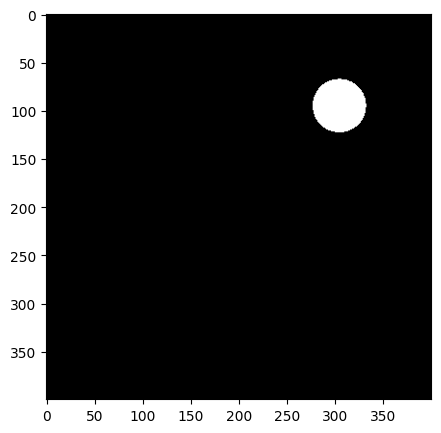

In [16]:
plt.rcParams["figure.figsize"]=5,5
fig = plt.figure()
ax = plt.axes()
ax.imshow(masks[9, 192, :, :], 'gray')

In [17]:
def createSubplotMasks(_masks, _center, slice, _n, _max=1, _title=None):
    if (_n//3 == _n/3):
        subl = (_n//3)
    else:    
        subl = (_n//3) + 1
    ml = []
    for i in range(subl):
        sl = [3*i, 3*i+1, 3*i+2]
        ml.append(sl)
    print(ml)
    #return
    
    fig, ax = plt.subplot_mosaic(ml, figsize=(12, 4*subl))

    for i in range (_n):
        ax[i].imshow(_masks[i,slice,:,:], cmap="gray")
        ax[i].set_title(f'{_center[i]}', fontsize = 10)
        #ax[i].plot([center, center], [lowL,highL], color="white", linewidth=0.7, linestyle='-.')
        #ax[i].plot([lowL,highL], [center, center], color="white", linewidth=0.7, linestyle='-.')

    #ax[5].set_axis_off()    

    if _title != None:
        fig.suptitle(_title, fontsize=12)

[[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]]


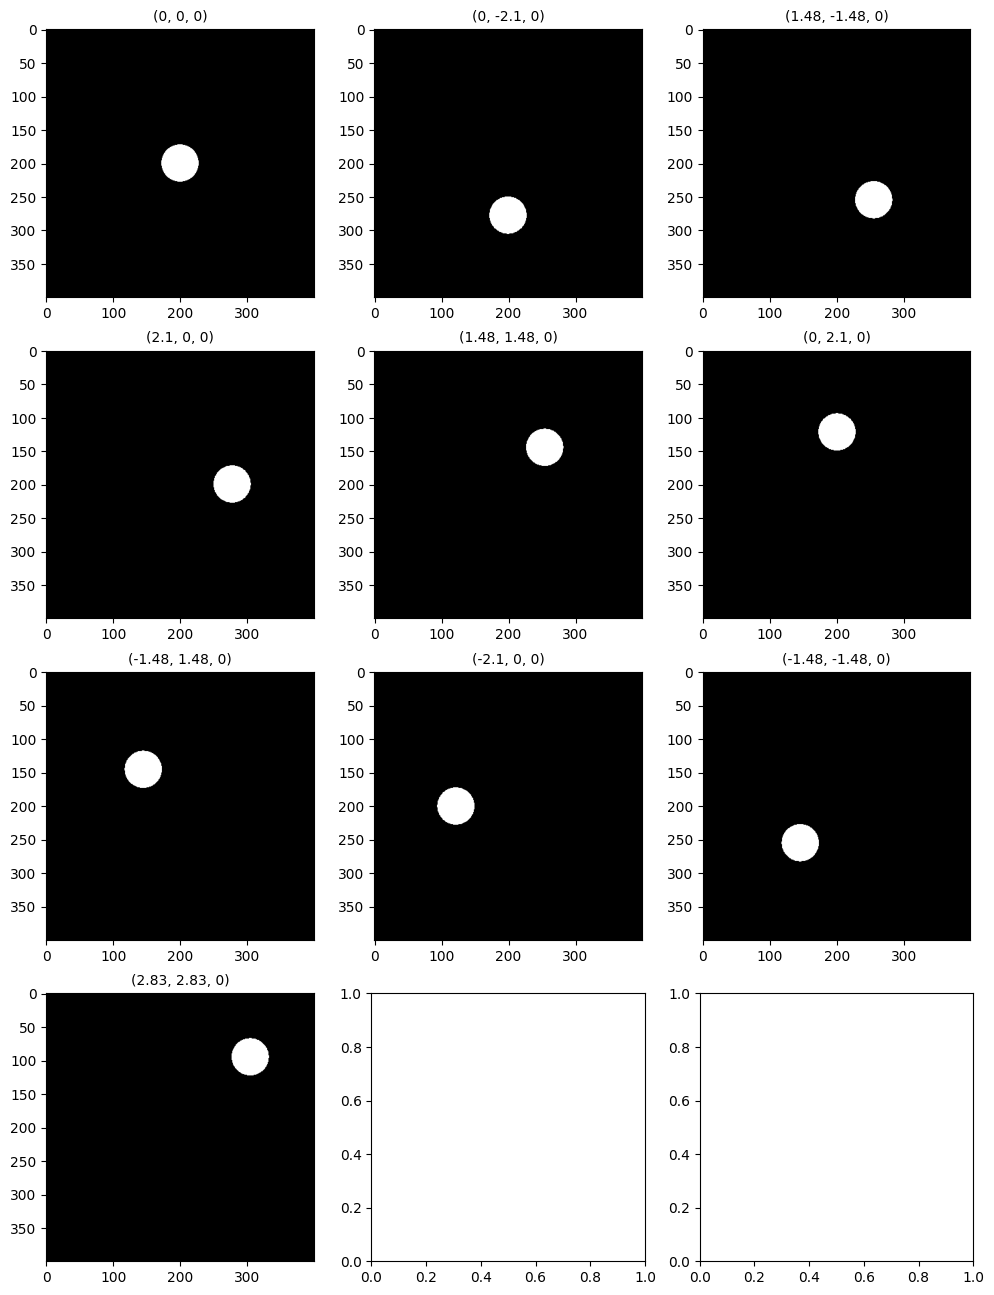

In [18]:
createSubplotMasks(masks, cilindMascDataCenter, 200, n)

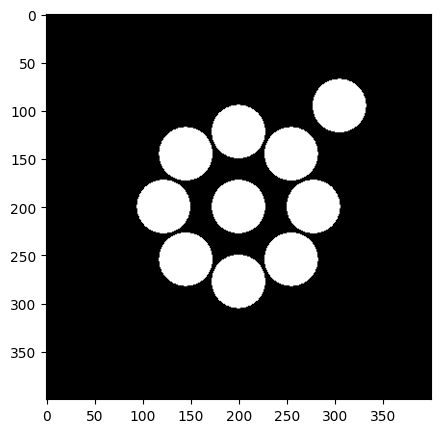

In [19]:
allMasks = np.zeros((img60k.shape[0], img60k.shape[1], img60k.shape[2]))

for i in range(n):
    allMasks[:, :, :] += masks[i, :, :, :]

plt.rcParams["figure.figsize"]=5,5
fig = plt.figure()
ax = plt.axes()
ax.imshow(allMasks[150, :, :], 'gray')

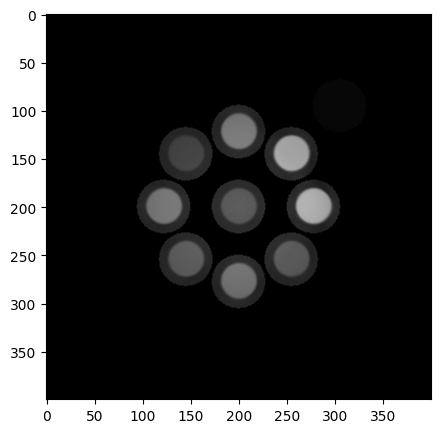

In [20]:
cylinders = np.multiply(allMasks, img60k)

plt.rcParams["figure.figsize"]=5,5
fig = plt.figure()
ax = plt.axes()
ax.imshow(cylinders[150, :, :], cmap='gray', vmin=0, vmax=65535)

In [21]:
print(cylinders.max(), cylinders.min(), cylinders.mean())

46198.0 0.0 2574.1974308118083


In [22]:
histogram, bin_edges = np.histogram(cylinders, bins=2047, range=(0, 65535))
bin_centers = np.zeros(len(histogram))
for i in range(len(bin_edges)-1):
    bin_centers[i] = (bin_edges[i]+bin_edges[i+1])/2

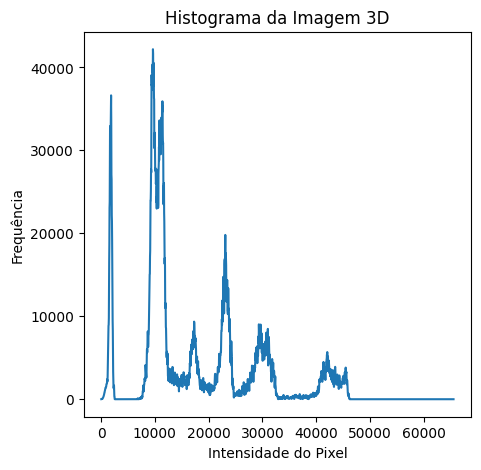

In [23]:
# Plotar histograma
plt.figure()
plt.plot(bin_centers[1:], histogram[1:])  # bin_edges tem um elemento a mais que histogram
plt.title('Histograma da Imagem 3D')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.show()

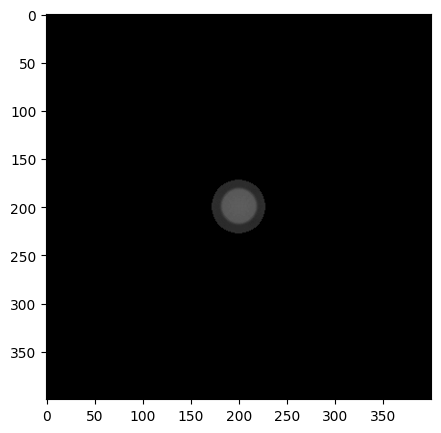

In [24]:
#Processamento do pico para i=0

peak0 = np.multiply(masks[0], img60k)

plt.rcParams["figure.figsize"]=5,5
fig = plt.figure()
ax = plt.axes()
ax.imshow(peak0[150, :, :], cmap='gray', vmin=0, vmax=65535)

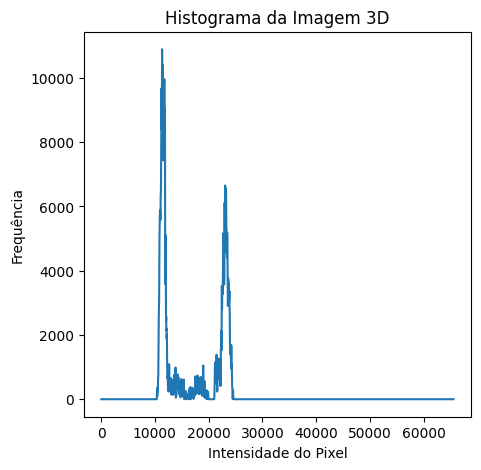

In [25]:
histPeak0, bin_edges = np.histogram(peak0, bins=2047, range=(0, 65535))

plt.figure()
plt.plot(bin_centers[1:], histPeak0[1:])  # bin_edges tem um elemento a mais que histogram
plt.title('Histograma da Imagem 3D')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.show()

In [26]:
#Função Gaussiana
def _gaussian(x, a, x0, sigma):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))

#Função que calcula os parâmetros de ajuste
def fitToGaussian(xdata, ydata, paramIni):
    paramVal, paramCov = curve_fit(_gaussian, xdata, ydata, p0=paramIni)

    return paramVal

562 875
[ 5540.19829051 23144.31540401   576.64291313]


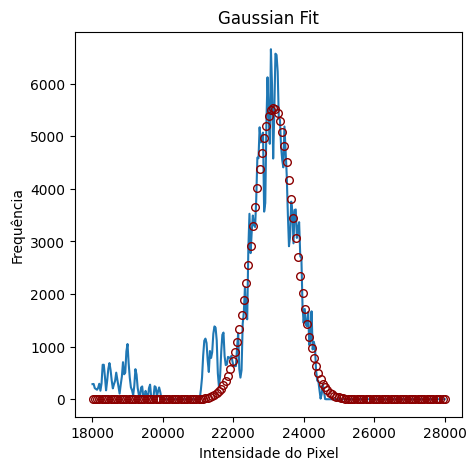

In [27]:
ini = np.argmax(bin_centers > 18000, 0) - np.argmax(bin_centers <= 18000, 0)
fim = np.argmax(bin_centers > 28000, 0) - np.argmax(bin_centers <= 28000, 0)

print(ini, fim)

xdata = bin_centers[ini:fim]
ydata = histPeak0[ini:fim]

paramFit = fitToGaussian(xdata, ydata, [3500, 23000, 5000])
print(paramFit)

plt.figure()
plt.plot(xdata, ydata)  # bin_edges tem um elemento a mais que histogram
plt.plot(xdata[::2], _gaussian(xdata[::2], paramFit[0], paramFit[1], paramFit[2]), linestyle='none', color='darkred', label='Values', linewidth=1.1, marker='.', markerfacecolor='None', markeredgecolor='darkred', markersize=11)
plt.title('Gaussian Fit')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.show()


Testado o conceito para um cilindro (pico), iremos a processar todos os picos individualmente

In [28]:
peakLabels = ['Water 1', 'Gd8mg', 'Gd2mg', 'I18mg', 'Ca140mg', 'I8mg', 'Adipose', 'Au8mg', 'Au2mg', 'Air']

n = len(peakLabels)

In [29]:
peaks = np.zeros((n, img60k.shape[0], img60k.shape[1], img60k.shape[2]))

for i in range(n):
    peaks[i,:,:,:] = np.multiply(masks[i], img60k)

[[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]]


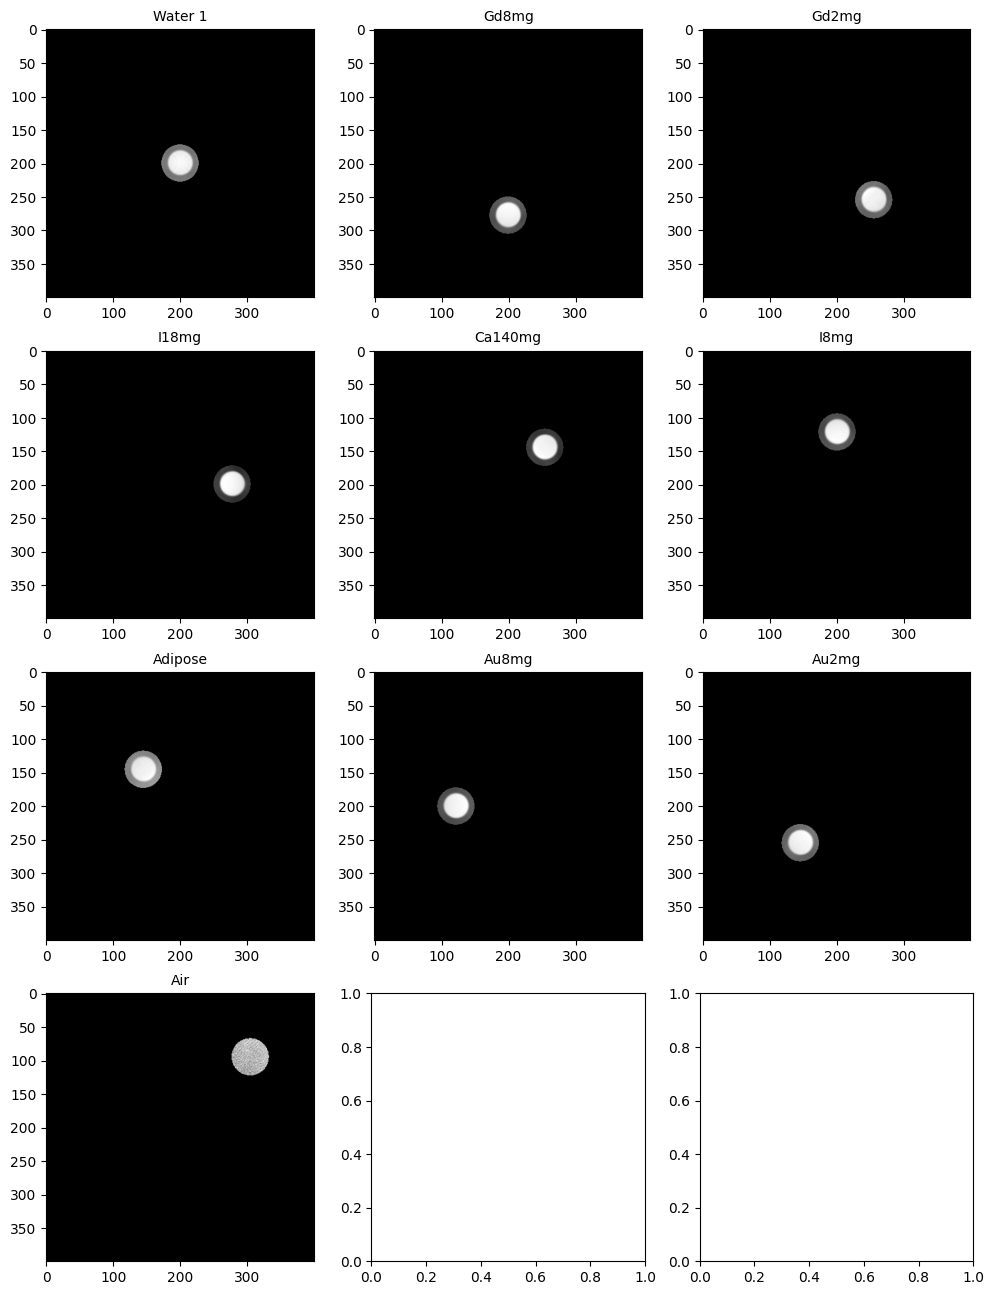

In [30]:
createSubplotMasks(peaks, peakLabels, 150, n)

In [31]:
_nBins = 2047

histPeaks = np.zeros((n, _nBins))

for i in range(n):
    histAux, bin_edges = np.histogram(peaks[i,:,:,:], bins=_nBins, range=(0, 65535))
    histPeaks[i,:] = histAux

In [32]:
def createSubplotHist(_hist, _bins, _labels, _n, _title=None):
    if (_n//3 == _n/3):
        subl = (_n//3)
    else:    
        subl = (_n//3) + 1
    ml = []
    for i in range(subl):
        sl = [3*i, 3*i+1, 3*i+2]
        ml.append(sl)
    print(ml)
    
    fig, ax = plt.subplot_mosaic(ml, figsize=(15, 5*subl))

    for i in range (_n):
        ax[i].plot(_bins[1:], _hist[i,1:])
        ax[i].set_title(f'{_labels[i]}', fontsize = 10)
        
    #ax[9].set_xlim(0,5000)

    if _title != None:
        fig.suptitle(_title, fontsize=12)

[[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]]


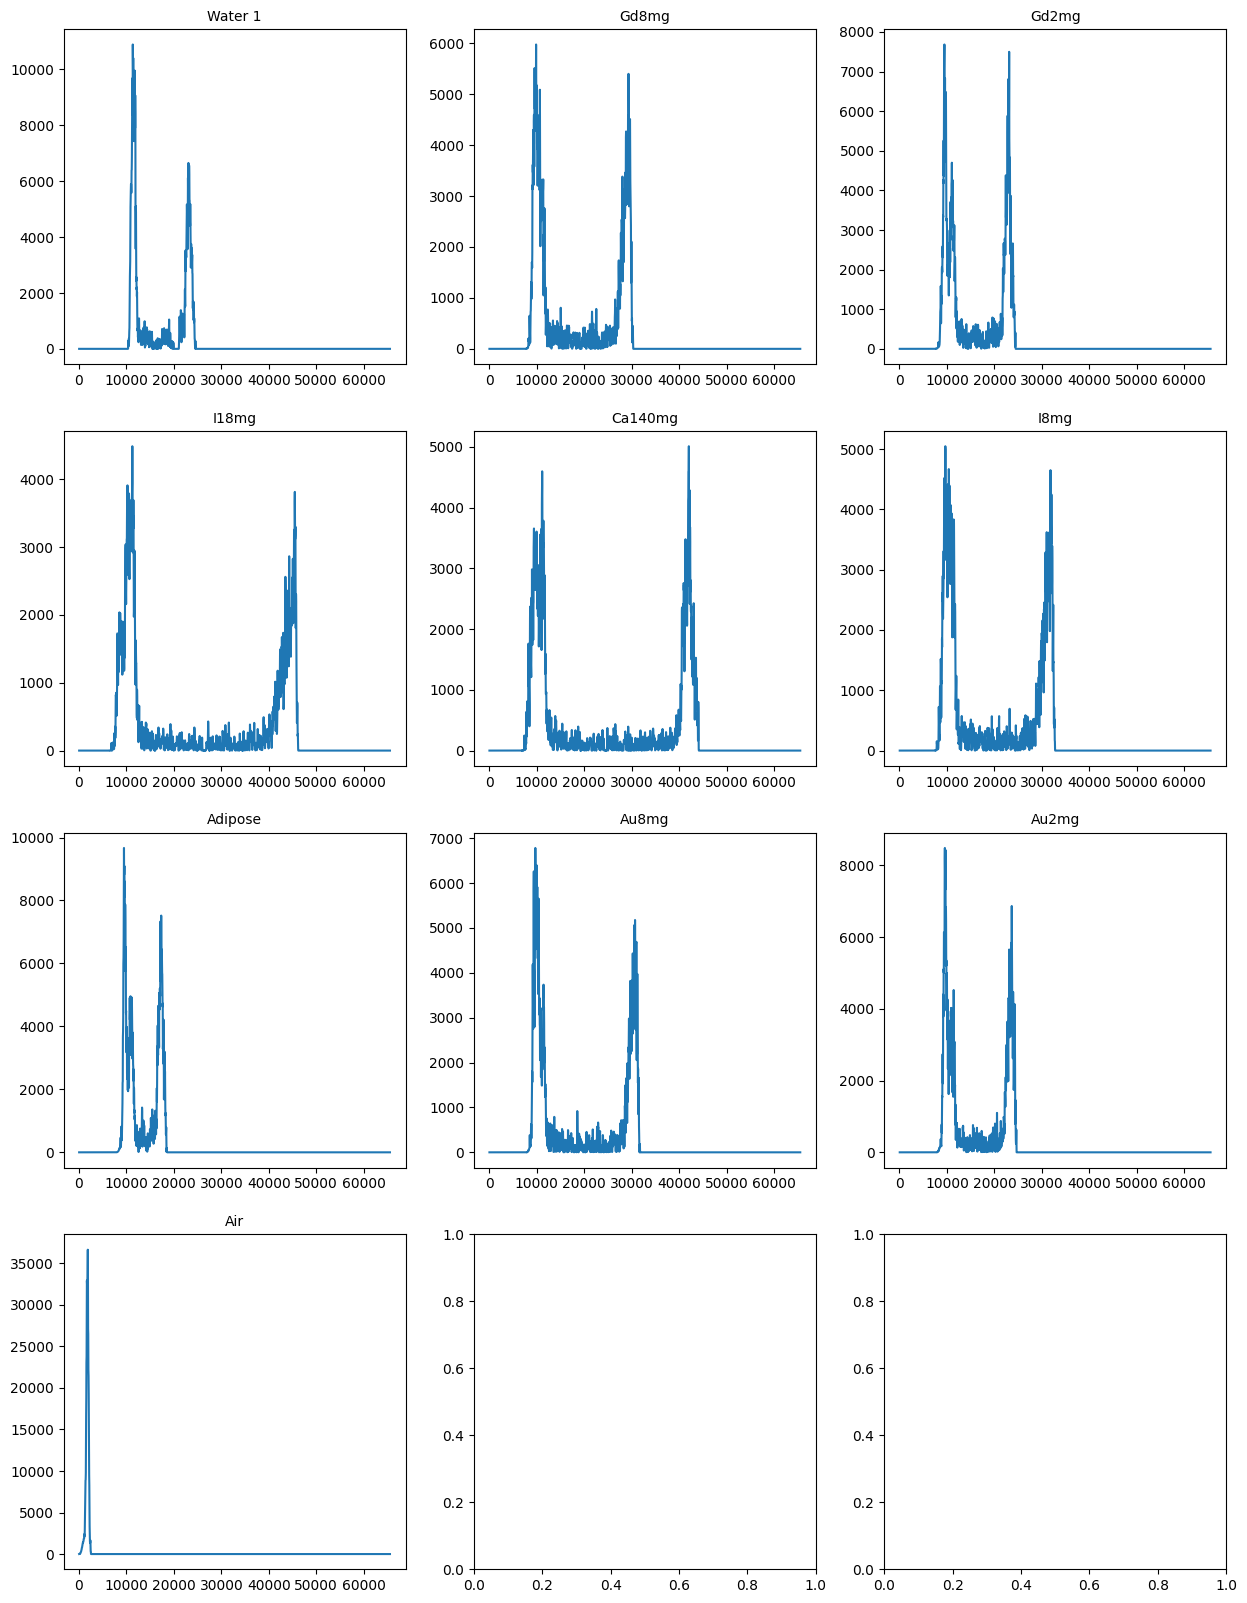

In [33]:
createSubplotHist(histPeaks, bin_centers, peakLabels, n)

In [34]:
fitIntervals = [[18000, 28000],
                [26000, 32000],
                [18000, 26000],
                [30000, 52000],
                [36000, 46000],
                [26000, 34000],
                [15000, 22000],
                [25000, 35534],
                [18000, 28534],
                [500, 3000]]

fitIniParams = [[3500, 23000, 5000],
                [5000, 27000, 4000],
                [3800, 24000, 5000],
                [1800, 48000, 6000],
                [2500, 42000, 5000],
                [2500, 33000, 5000],
                [3800, 18000, 4000],
                [3000, 30000, 5000],
                [3500, 23000, 5000],
                [17500, 2000, 1500]]

In [35]:
fitParams = []

for i in range(n):
    ini = np.argmax(bin_centers > fitIntervals[i][0], 0) - np.argmax(bin_centers <= fitIntervals[i][0], 0)
    fim = np.argmax(bin_centers > fitIntervals[i][1], 0) - np.argmax(bin_centers <= fitIntervals[i][1], 0)  
    if (fim == 0):
        fim = len(bin_centers)

    print(ini, fim)  

    xdata = bin_centers[ini:fim]
    ydata = histPeaks[i, ini:fim]
    
    fitParams.append(fitToGaussian(xdata, ydata, fitIniParams[i]))

    #print(ini, fim, fitParams)

#print(fitParams)    

562 875
812 1000
562 812
937 1624
1124 1437
812 1062
469 687
781 1110
562 891
16 94


In [36]:
for i in range(n):
    print(fitParams[i]) 
#print(fitParams[0][0], fitParams[0][1], fitParams[0][2]) 

[ 5540.19829051 23144.31540401   576.64291313]
[ 3663.42543874 28903.52425698  -871.72873745]
[ 4999.93244586 22877.11253586  -634.33393393]
[ 2188.75408956 44357.70965308  1401.52463298]
[ 3226.47774054 41863.48489247  -981.28127069]
[ 3192.0761226  31231.82821813   994.99796627]
[ 6074.68481679 17256.24638132   547.01261401]
[ 3922.53738695 30339.23082197   816.27738555]
[ 4810.85363453 23394.76724051   676.03460723]
[34461.24464378  1797.12284203  -234.04418522]


In [37]:
def createSubplotHistGaussFit(_hist, _bins, _labels, _fitIntervals, _fitParams, _n, _title=None):
    if (_n//3 == _n/3):
        subl = (_n//3)
    else:    
        subl = (_n//3) + 1
    ml = []
    for i in range(subl):
        sl = [3*i, 3*i+1, 3*i+2]
        ml.append(sl)
    print(ml)
    
    fig, ax = plt.subplot_mosaic(ml, figsize=(12, 4*subl))

    for i in range (_n):
        ini = np.argmax(_bins > _fitIntervals[i][0], 0) - np.argmax(_bins <= _fitIntervals[i][0], 0)
        fim = np.argmax(_bins > _fitIntervals[i][1], 0) - np.argmax(_bins <= _fitIntervals[i][1], 0) 
        if (fim == 0):
            fim = len(bin_centers)   

        _xdata = bin_centers[ini:fim]
        _ydata = _hist[i, ini:fim]

        ax[i].plot(_xdata, _ydata)        
        ax[i].plot(_xdata[::2], _gaussian(_xdata[::2], _fitParams[i][0], _fitParams[i][1], _fitParams[i][2]), linestyle='none', color='darkred', label='Values', linewidth=1.1, marker='.', markerfacecolor='None', markeredgecolor='darkred', markersize=10)
        ax[i].set_title(f'{_labels[i]}', fontsize = 10)
        

    if _title != None:
        fig.suptitle(_title, fontsize=12)

[[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11]]


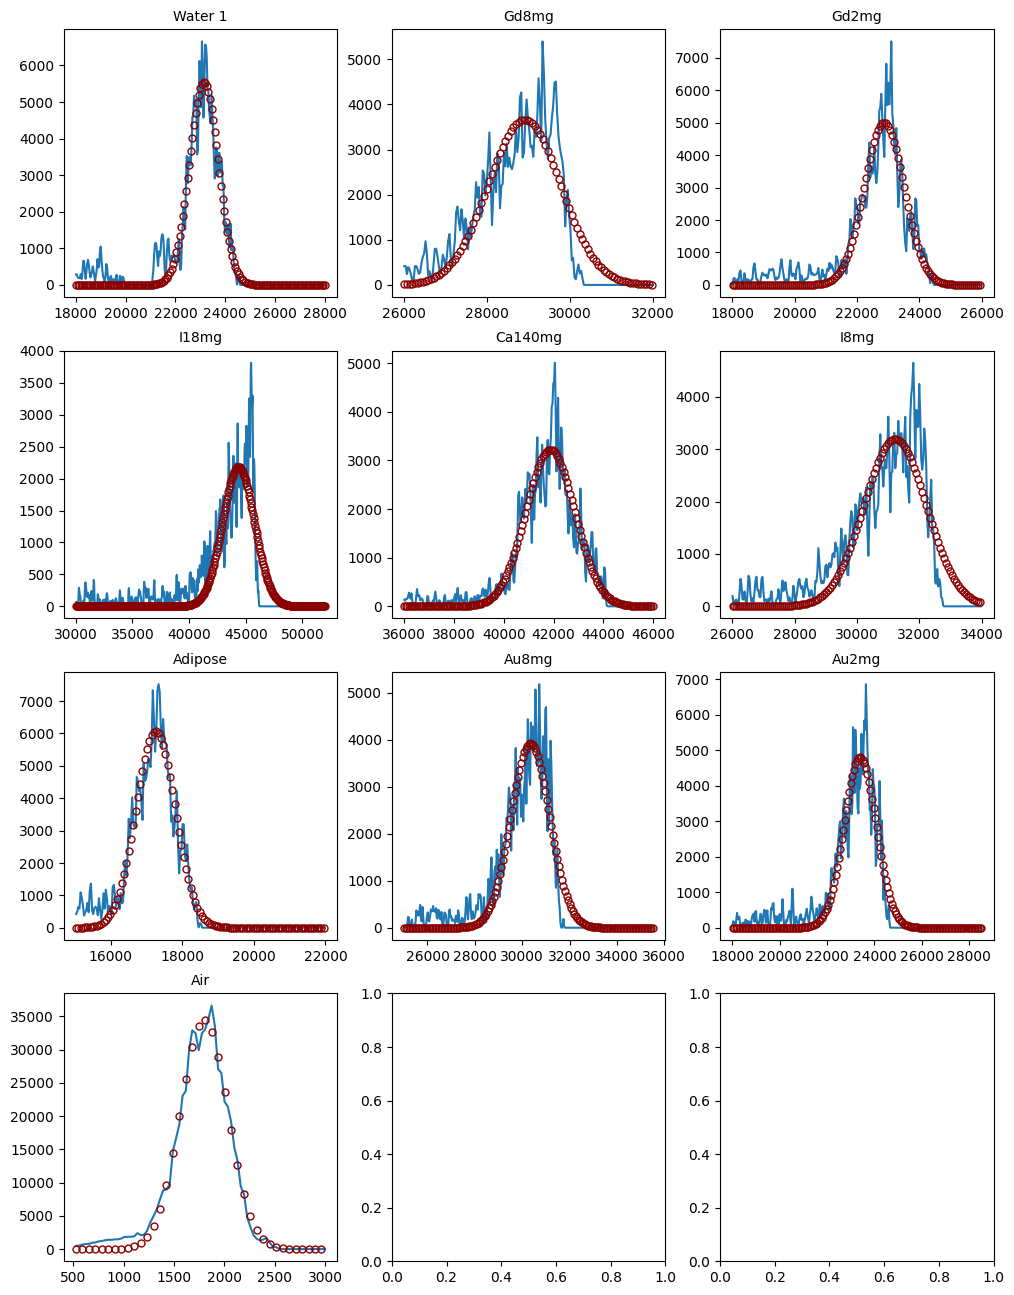

In [38]:
createSubplotHistGaussFit(histPeaks, bin_centers, peakLabels, fitIntervals, fitParams, n)

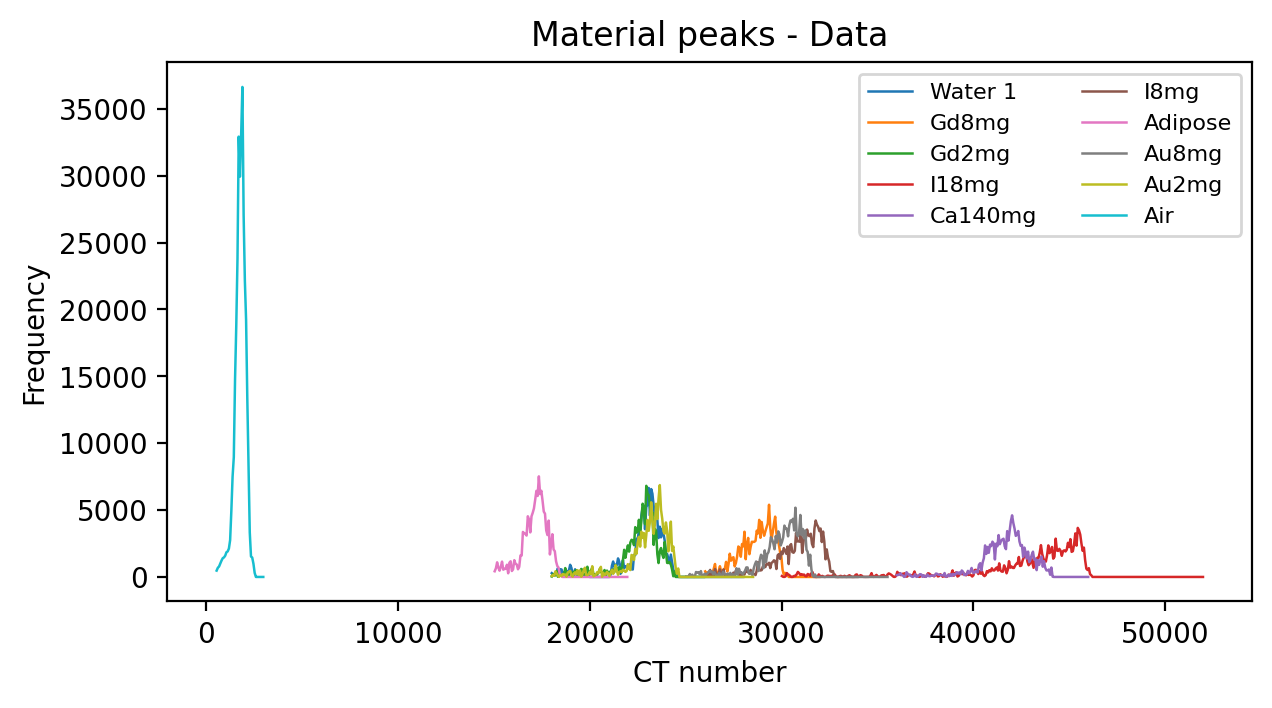

In [39]:
# Plotar histogramas de todos os picos, dados reais
plt.figure(figsize=(7, 3.5), dpi=200)

for i in range(n):
    ini = np.argmax(bin_centers > fitIntervals[i][0], 0) - np.argmax(bin_centers <= fitIntervals[i][0], 0)
    fim = np.argmax(bin_centers > fitIntervals[i][1], 0) - np.argmax(bin_centers <= fitIntervals[i][1], 0)  
    if (fim == 0):
        fim = len(bin_centers)

    xdata = bin_centers[ini:fim:2]
    ydata = histPeaks[i, ini:fim:2]
    plt.plot(xdata, ydata, label=peakLabels[i], linewidth=0.9) 

plt.title('Material peaks - Data')
plt.xlabel('CT number')
plt.ylabel('Frequency')
plt.legend(loc="upper right", ncol=2, fontsize="8")
plt.show()

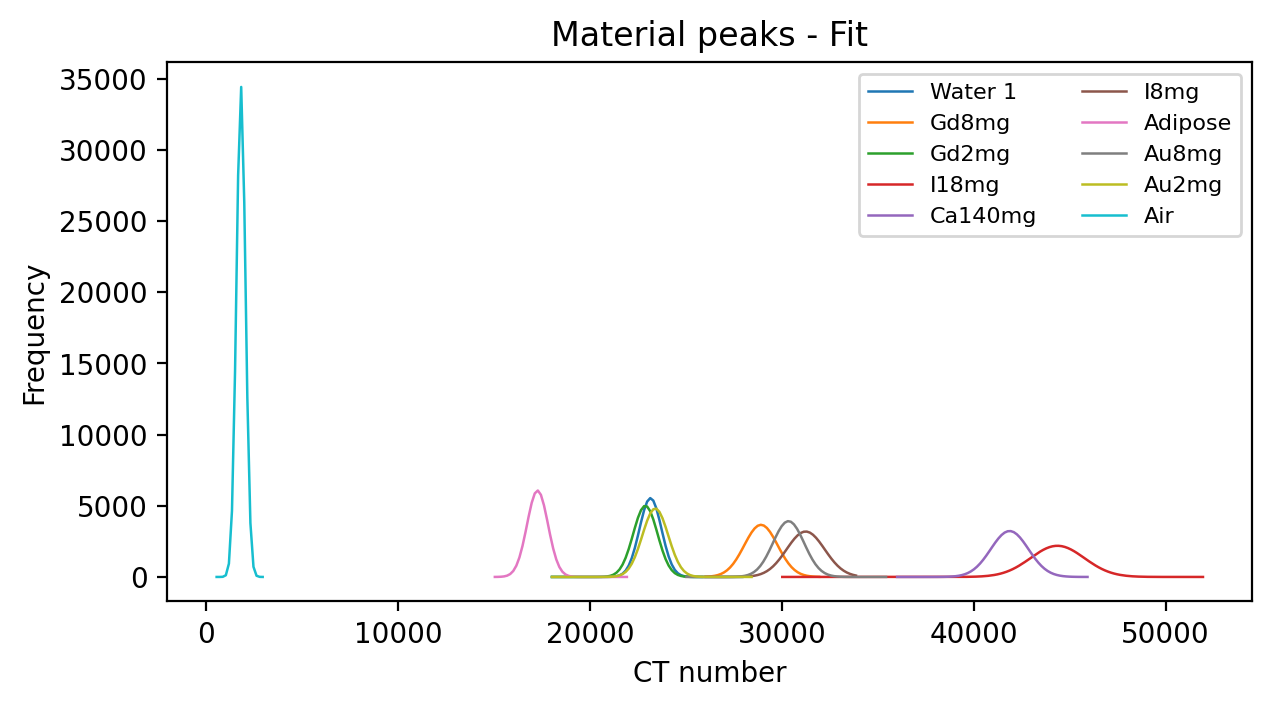

In [40]:
# Plotar histogramas de todos os picos, dados ajustados
plt.figure(figsize=(7, 3.5), dpi=200)

for i in range(n):
    ini = np.argmax(bin_centers > fitIntervals[i][0], 0) - np.argmax(bin_centers <= fitIntervals[i][0], 0)
    fim = np.argmax(bin_centers > fitIntervals[i][1], 0) - np.argmax(bin_centers <= fitIntervals[i][1], 0)  
    if (fim == 0):
        fim = len(bin_centers)

    xdata = bin_centers[ini:fim:5]
    ydata = _gaussian(xdata, fitParams[i][0], fitParams[i][1], fitParams[i][2])
    plt.plot(xdata, ydata, label=peakLabels[i], linewidth=0.9) 

plt.title('Material peaks - Fit')
plt.xlabel('CT number')
plt.ylabel('Frequency')
plt.legend(loc="upper right", ncol=2, fontsize="8")
plt.show()

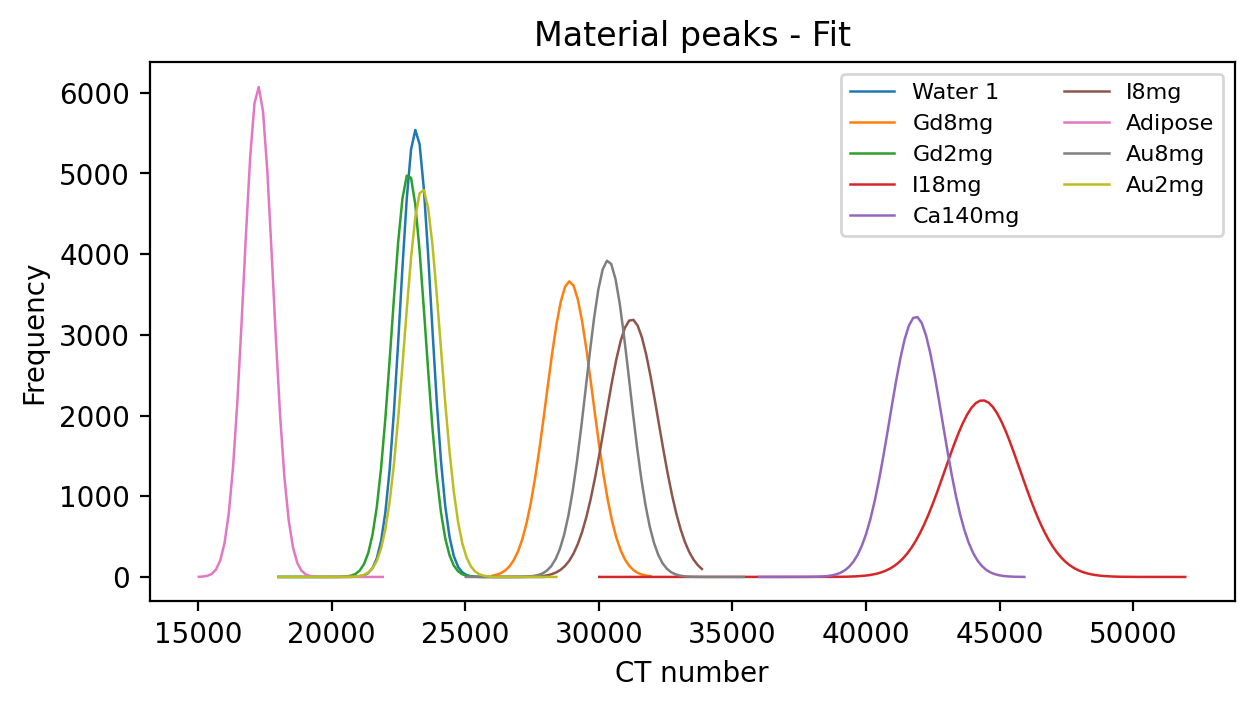

In [41]:
# Plotar histogramas de todos os picos, dados ajustados
plt.figure(figsize=(7, 3.5), dpi=200)

for i in range(n-1):
    ini = np.argmax(bin_centers > fitIntervals[i][0], 0) - np.argmax(bin_centers <= fitIntervals[i][0], 0)
    fim = np.argmax(bin_centers > fitIntervals[i][1], 0) - np.argmax(bin_centers <= fitIntervals[i][1], 0)  
    if (fim == 0):
        fim = len(bin_centers)

    xdata = bin_centers[ini:fim:5]
    ydata = _gaussian(xdata, fitParams[i][0], fitParams[i][1], fitParams[i][2])
    plt.plot(xdata, ydata, label=peakLabels[i], linewidth=0.9) 

plt.title('Material peaks - Fit')
plt.xlabel('CT number')
plt.ylabel('Frequency')
plt.legend(loc="upper right", ncol=2, fontsize="8")
plt.show()